# Does a neural network know which paintings you will remember?
**Reading:** Davis, T. M., & Bainbridge, W. A. (2023). Memory for artwork is predictable. *PNAS, 120*(28), e2302389120.

**What you will do**
1. Load the paintings and human memorability scores
2. Guess which paintings are memorable yourself
3. Let ResMem predict memorability
4. Correlate ResMem with humans
5. Look at where ResMem and humans disagree

**Before you start:** go to *Runtime → Change runtime type* and select a **GPU**. Then run the cells from top to bottom with *Shift + Enter*.

## Setup
This installs ResMem (if needed) and loads the libraries. It takes about a minute the first time.

In [16]:
%pip install -q resmem
import warnings; warnings.filterwarnings("ignore")
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from PIL import Image
import torch
from resmem import ResMem, transformer
import os, zipfile

Note: you may need to restart the kernel to use updated packages.


In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [18]:
REPO = "https://raw.githubusercontent.com/ekin-doga/Update_Cognitive_Neuroscience_NeuroAI/main/Week0-ResMem-DavisBainbridge2023/data/"
SCORES_FILE, IMAGES_ZIP = "art_memorability.csv", "art_images.zip"
LOCAL_DATA = "data/" # used instead of GitHub if the files are there (e.g. when running locally)

## 1. Load the paintings and the human memory scores
Each row is one painting. `human_memorability` is how well people remembered it in the online experiment. It is the **corrected recognition** score: the proportion of people who recognised the painting when it repeated (hits), minus the proportion who wrongly claimed to have seen it before (false alarms).

In [19]:
import os, zipfile

In [20]:
def get(name):
    """Return a local path to a data file, downloading it from GitHub if needed."""
    local = os.path.join(LOCAL_DATA, name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        r = requests.get(REPO + name, timeout=120); r.raise_for_status()
        open(name, "wb").write(r.content)
    return name

all_data = pd.read_csv(get(SCORES_FILE))
zipfile.ZipFile(get(IMAGES_ZIP)).extractall("art_images")
print(f"{len(all_data)} paintings available")

500 paintings available


In [21]:
N_PAINTINGS = 200    # how many paintings to use today (more = slower, but more reliable)
SEED = 1             # change this to get a different random subset

data = all_data.sample(n=min(N_PAINTINGS, len(all_data)), random_state=SEED).reset_index(drop=True)
images = [Image.open(os.path.join("art_images", f)).convert("RGB") for f in data["filename"]]
print(f"Using {len(data)} paintings")
data.head()

Using 200 paintings


,filename,aic_id,title,artist,human_memorability,resmem_paper
0,97884.jpg,97884,"A Glimpse into Hell, or Fear",Elihu Vedder,0.558,0.782026
1,74034.jpg,74034,Baptismal Certificate of Catharina Wentzelsin,NaN,0.751,0.874147
2,131822.jpg,131822,"Four Princes in Procession Visit a Sage, page ...",NaN,0.425,0.640977
3,26684.jpg,26684,La Piana,Edward Lear,0.439,0.587517
4,16584.jpg,16584,"Houses of Parliament, London",Claude Monet,0.750,0.605454


## 3. Your turn first: which of these will people remember?

Below are  random paintings. **Before running the next cell**, rank them from most to least memorable and write your ranking down. Compare with your neighbour: do you agree?

In [22]:
n_image = 10 # number of images to display
random_s = 11 # change this to see different images

In [23]:
def show_grid(df, images, label_cols, n_cols=round(n_image/2), title=None, sort_by=None):
    """Show paintings in a grid with selected columns written underneath.
    If sort_by is a column name, paintings are shown from the lowest to the highest value."""
    if sort_by is not None:
        df = df.sort_values(sort_by)

    def label(c, value):
        if c == "title":                        # show the painting's title
            return str(value)[:26]
        if isinstance(value, float):
            return f"{c}: {value:.2f}"
        return f"{c}: {str(value)[:26]}"

    n = len(df); n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.6 * n_cols, 3.0 * n_rows))
    for ax, (idx, row) in zip(np.atleast_1d(axes).ravel(), df.iterrows()):
        ax.imshow(images[idx])
        ax.set_title("\n".join(label(c, row[c]) for c in label_cols), fontsize=8)
    for ax in np.atleast_1d(axes).ravel():
        ax.axis("off")
    if title: fig.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()

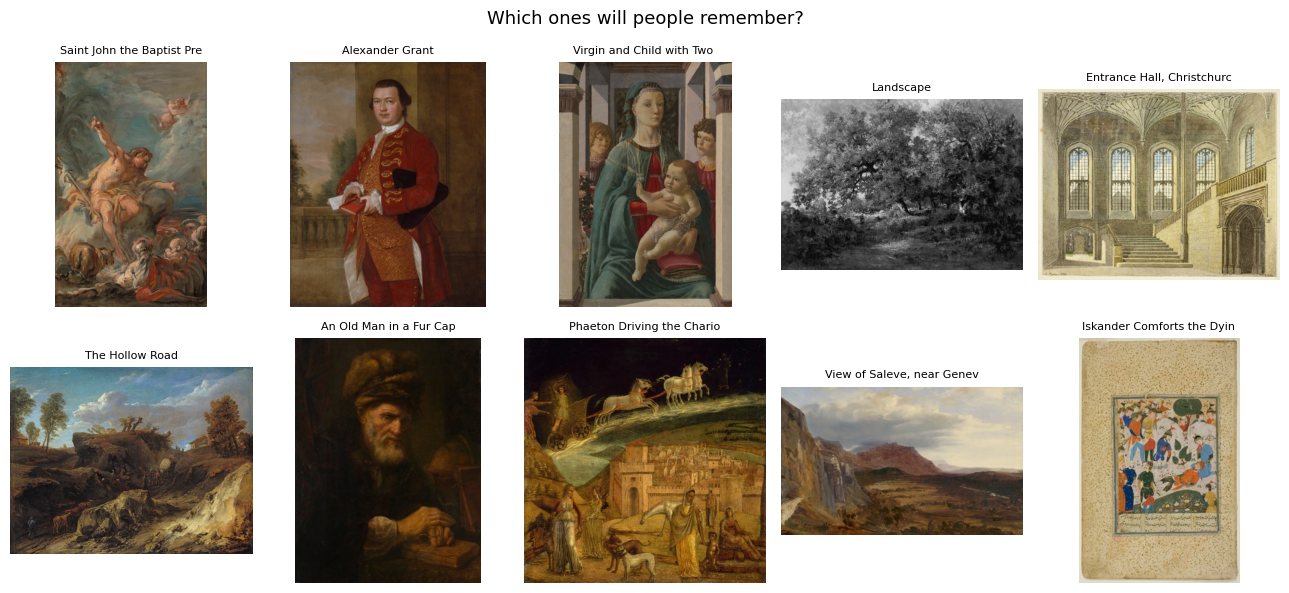

In [24]:
guess_set = data.sample(n_image, random_state=random_s)
show_grid(guess_set, images, label_cols=["title"], title="Which ones will people remember?")

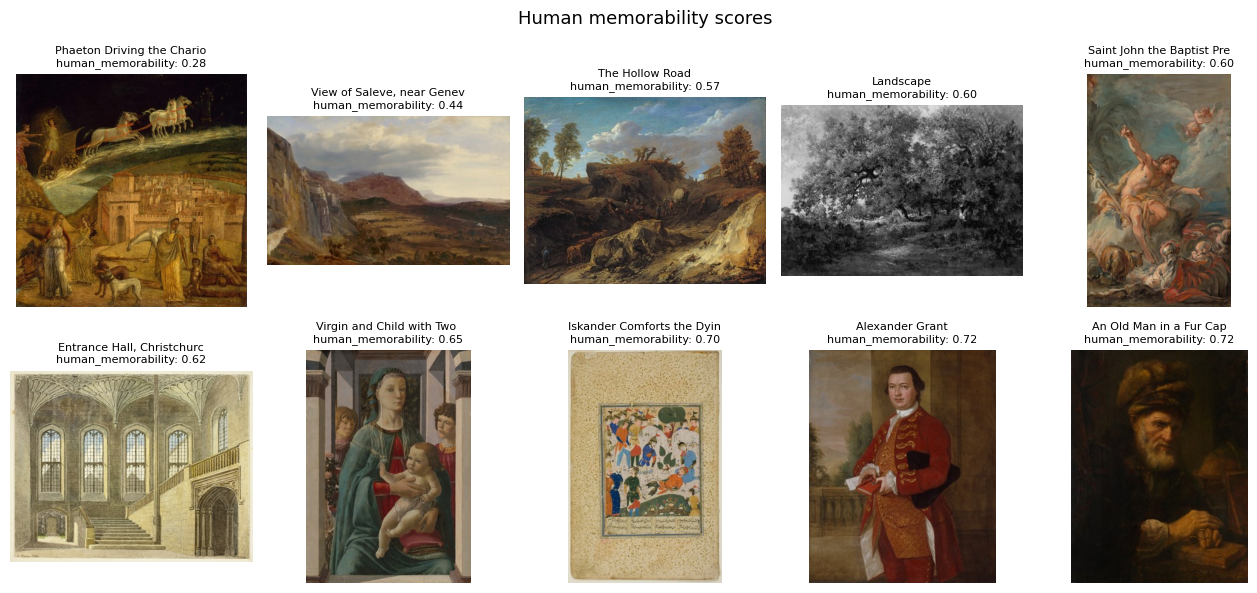

In [25]:
# Reveal the human scores
show_grid(guess_set, images, label_cols=["title", "human_memorability"], title="Human memorability scores",sort_by="human_memorability")

## 4. Let ResMem predict memorability

ResMem was trained on everyday photographs (the LaMem and MemCat datasets), **not on art**. It has never seen these paintings or any human data about them.

In [26]:
# Load ResMem with its trained weights (pretrained=True),
# move it to the GPU or CPU (see the Setup cell),
# and switch it to evaluation mode (.eval()), which turns off
# training-only behaviour such as dropout, so predictions are stable

model = ResMem(pretrained=True).to(device).eval()

def predict_memorability(imgs, batch_size=32):
    """Return ResMem's memorability prediction for each image in `imgs`."""
    scores = []

    # We only make predictions and don't train the model,
    # so PyTorch doesn't need to track gradients. This saves memory and time.
    with torch.no_grad():

        # Process the images in batches of `batch_size` (here 32) at a time,
        # which is much faster than one by one
        for i in range(0, len(imgs), batch_size):

            # Prepare each image the way ResMem expects it: `transformer`
            # resizes and crops it to 227 x 227 pixels and turns it into a tensor
            # (PyTorch's array format). torch.stack combines the images into one
            # batch, and .to(device) moves it to the same device as the model.
            batch = torch.stack([transformer(img) for img in imgs[i:i + batch_size]]).to(device)

            # Run the batch through the network. The output has shape (batch_size, 1):
            # .squeeze(1) turns it into a flat list of scores, .cpu() moves it back
            # from the GPU, and .numpy() converts it to a normal numpy array.
            scores.extend(model(batch).squeeze(1).cpu().numpy())

    return np.array(scores)

# Predict memorability for all paintings and store it as a new column
data["resmem"] = predict_memorability(images)

# Show the first few rows: human scores next to ResMem's predictions
data[["title", "human_memorability", "resmem"]].head()

,title,human_memorability,resmem
0,"A Glimpse into Hell, or Fear",0.558,0.763156
1,Baptismal Certificate of Catharina Wentzelsin,0.751,0.862490
2,"Four Princes in Procession Visit a Sage, page ...",0.425,0.645114
3,La Piana,0.439,0.606191
4,"Houses of Parliament, London",0.750,0.632167


**Quick check:** the authors ran ResMem on the same paintings. Your predictions should almost exactly match theirs (small differences come from image resizing).

In [ ]:
r = spearmanr(data["resmem"], data["resmem_paper"])[0]
print(f"Your ResMem vs the authors' ResMem: ρ = {r:.3f}")

How did ResMem do on the paintings you ranked? Did it agree more with you or with the humans?

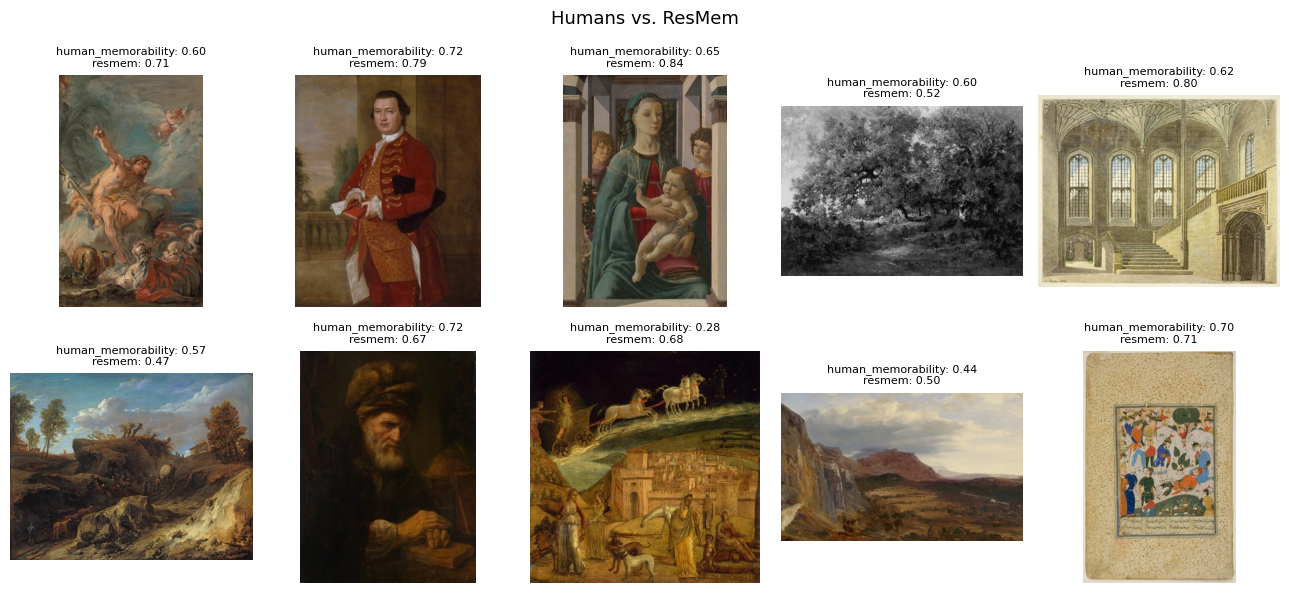

In [13]:
show_grid(data.loc[guess_set.index], images, label_cols=["human_memorability", "resmem"],
          title="Humans vs. ResMem")

## 5. The key result: does ResMem predict human memory?

We use a **Spearman correlation**, which only cares about the *ranking* of paintings. That is the usual choice for memorability scores.

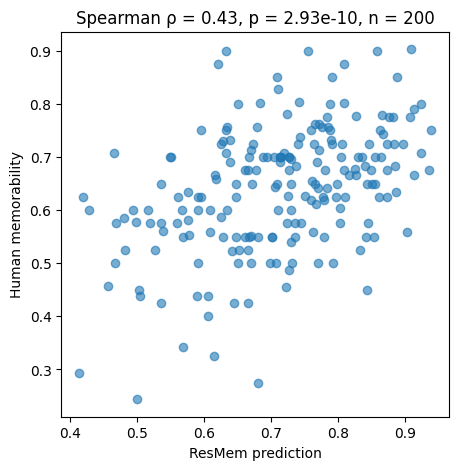

In [14]:
rho, p = spearmanr(data["resmem"], data["human_memorability"])

plt.figure(figsize=(5, 5))
plt.scatter(data["resmem"], data["human_memorability"], alpha=0.6)
plt.xlabel("ResMem prediction"); plt.ylabel("Human memorability")
plt.title(f"Spearman ρ = {rho:.2f}, p = {p:.3g}, n = {len(data)}")
plt.show()

**Think about it:**
- Is the correlation positive? How strong is it?
- Rerun sections 1–5 with a different `SEED`. How much does ρ change? What does that tell you about using only ~200 paintings?
- Compare your number with the one reported in the paper. Why might they differ?

## 6. Where do ResMem and humans disagree?
The most informative paintings are often the ones the model gets wrong.

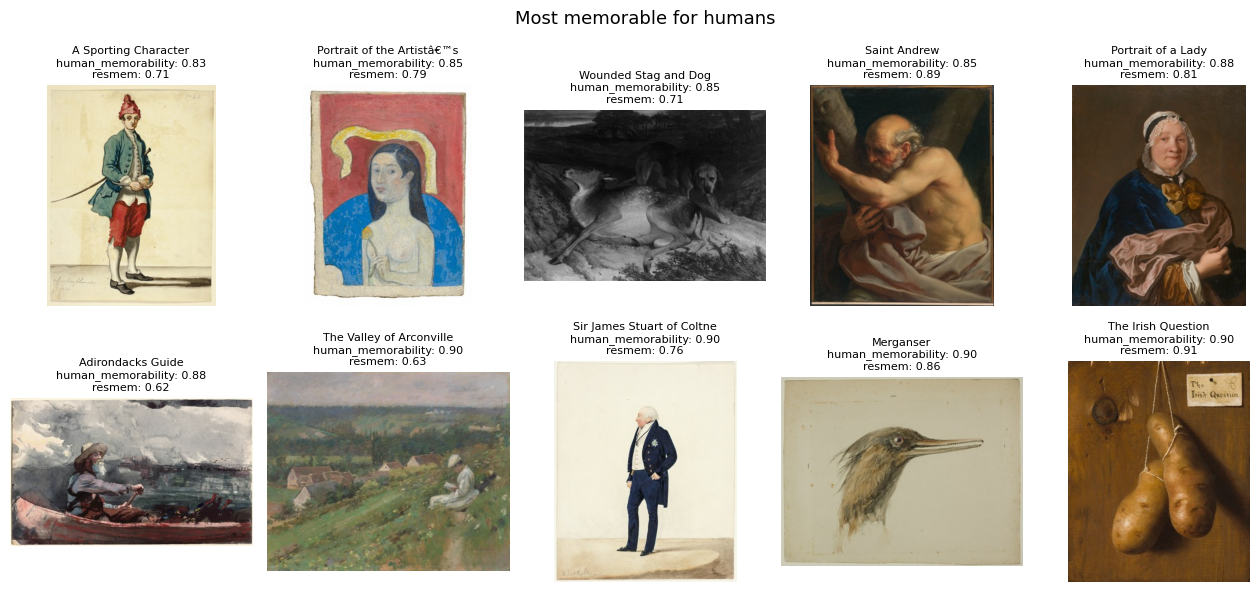

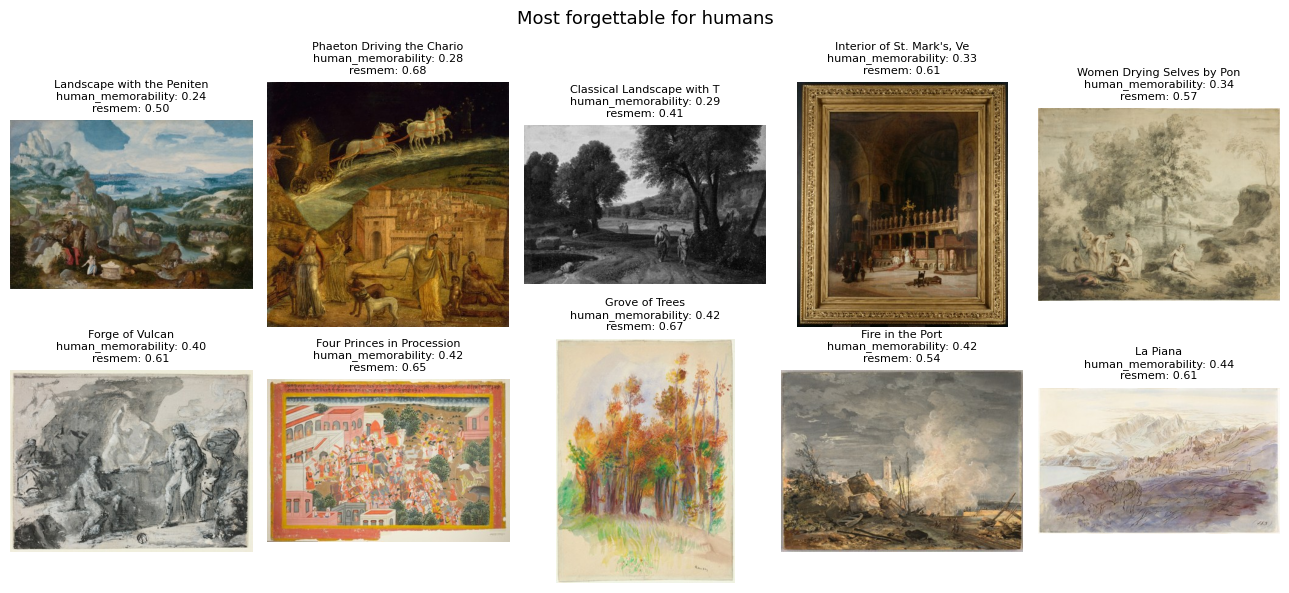

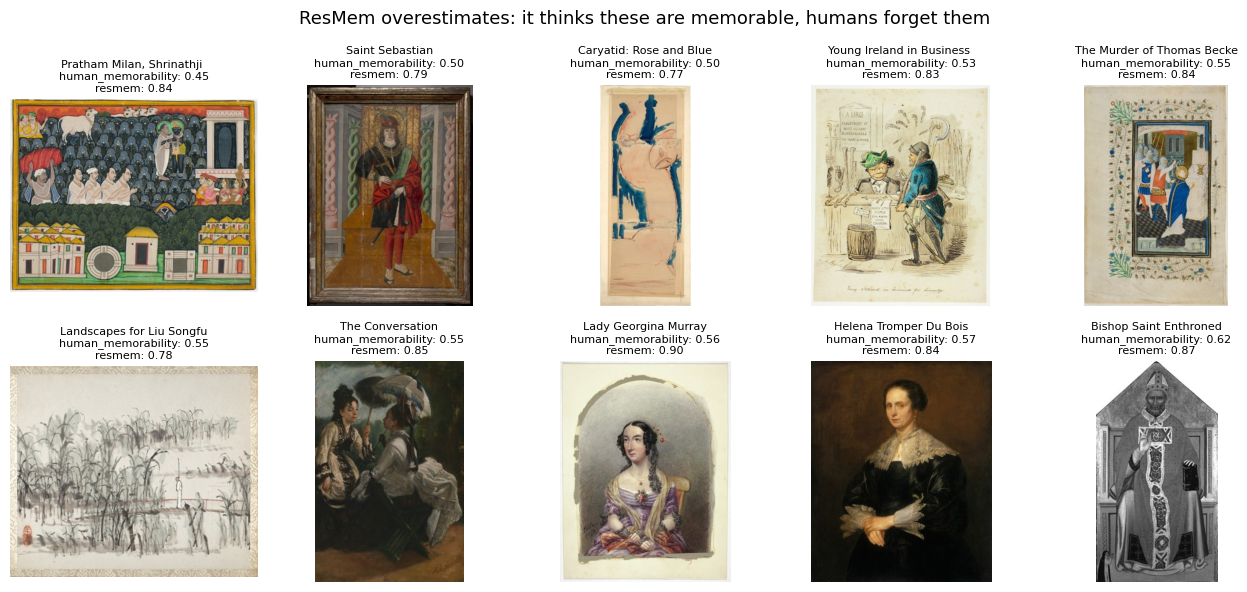

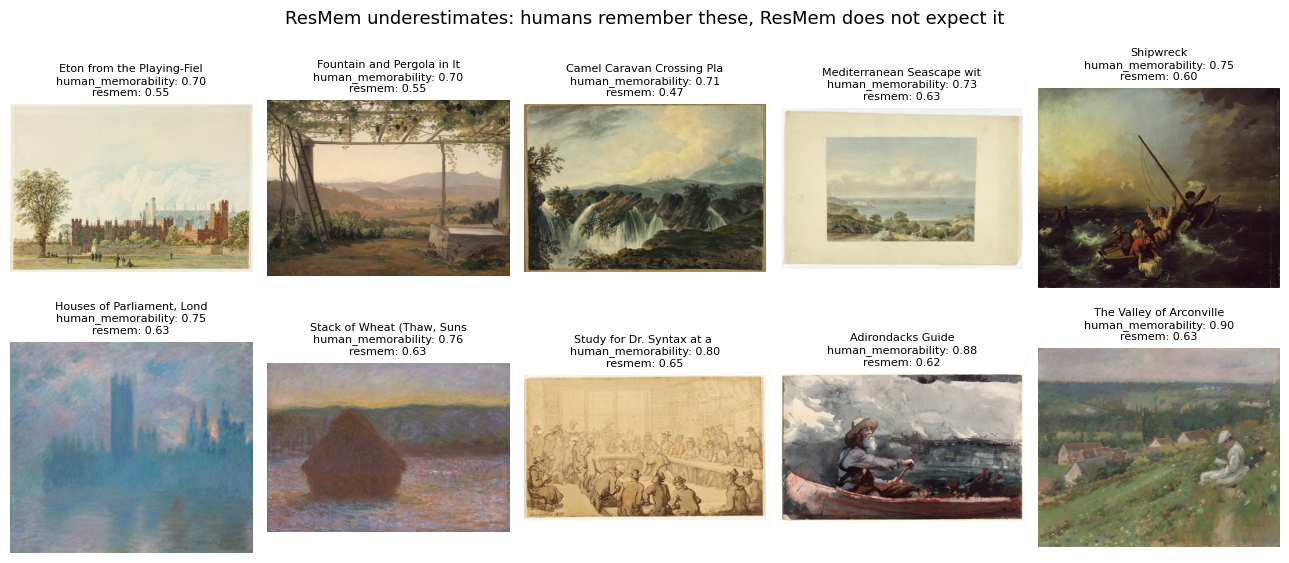

In [15]:
# Convert both scores to ranks (0 = lowest, 1 = highest) so they are on the same scale
data["human_rank"] = data["human_memorability"].rank(pct=True)
data["resmem_rank"] = data["resmem"].rank(pct=True)

# Positive disagreement: ResMem ranks the painting higher than humans do
# Negative disagreement: humans rank it higher than ResMem does
data["disagreement"] = data["resmem_rank"] - data["human_rank"]

# Columns written under each painting
labels = ["title", "human_memorability", "resmem"]

show_grid(data.nlargest(n_image, "human_memorability"), images, labels,
          title="Most memorable for humans", sort_by="human_memorability")
show_grid(data.nsmallest(n_image, "human_memorability"), images, labels,
          title="Most forgettable for humans", sort_by="human_memorability")
show_grid(data.nlargest(n_image, "disagreement"), images, labels,
          title="ResMem overestimates: it thinks these are memorable, humans forget them",
          sort_by="human_memorability")
show_grid(data.nsmallest(n_image, "disagreement"), images, labels,
          title="ResMem underestimates: humans remember these, ResMem does not expect it",
          sort_by="human_memorability")

## 7. Discussion questions

1. Look at the paintings ResMem got wrong. Is there a pattern? What might humans use that ResMem does not have access to?
2. ResMem was trained on photographs of everyday scenes. Why does it work on paintings at all?
3. The paper found that ResMem could also predict which paintings are *famous*. How would you explain that? Does it mean fame is "just" visual?